# Intro to Programming IV: Modeling and Simulations

[Link to Google Colab](https://colab.research.google.com/drive/1PpdZODPrZrr5O0IqSYEwusjWYXYyOodP?usp=sharing)

In this lecture, we will:

* Learn about different types of computational models
* Design a model in pseudocode
* Simulate bacterial chemotaxis
* Quantify a computational model


In [13]:
import matplotlib.pyplot as plt # various plotting functions
import numpy as np              # various math functions
import math
import copy                     # used to deeply copy class objects (why is this important? :thinking:)

# Part 1: Setting Up the Model

In [14]:
savestates = []
all_cells = []

def savestate():
    savestates.append(copy.deepcopy(all_cells))

def display_savestate(state):
    soa = map(lambda c: c.getvars(), state)
    X, Y, Z, U = zip(*soa)

    fig = plt.figure()
    plt.quiver(X, Y, Z, U)
    plt.show()

In [37]:
class Cell:
    # internal variables to track
    x = 0;
    y = 0;
    angle = 0;

    # functions
    def randomize(self):
        self.x = np.random.rand() * 20 - 10
        self.y = np.random.rand() * 20 - 10
        self.angle = np.random.rand() * 360

    def getvars(self):
        return [self.x, self.y, np.cos(np.radians(self.angle)), np.sin(np.radians(self.angle))]

    def update(self):
        ############################################################
        ##### Main movement function ###############################
        ############################################################
        tumbling_probability = 1 / math.dist([self.x,self.y],[20,0]) # <- chemoattractant at (20,0)
        ############################################################

        if (tumbling_probability > np.random.rand()):
            # if not tumbling, move
            self.x = self.x + np.cos(np.radians(self.angle))
            self.y = self.y + np.sin(np.radians(self.angle))
        else:
            # if tumbling, tumble
            self.angle = self.angle + (np.random.rand() * 360) - 180

In [38]:
def initialize_game():
    savestates.clear()
    all_cells.clear()

    for i in np.arange(100):
        new_cell = Cell() # defines new instance of the class
        new_cell.randomize() # randomize position + vector
        all_cells.append(new_cell) # add to our larger dataset

# Part 2: Running the Model

In [39]:
initialize_game()
savestate()

for t in np.arange(100):
    for c in all_cells:
        c.update()
    savestate()

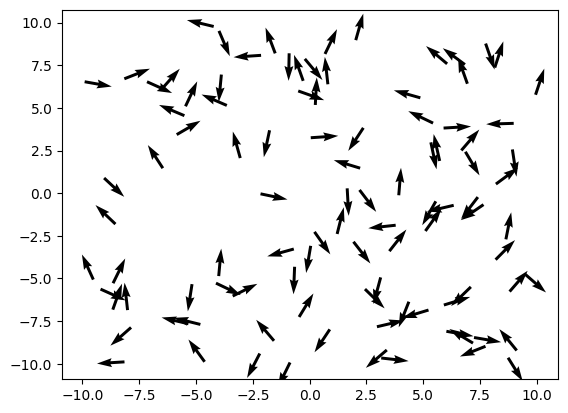

In [40]:
display_savestate(savestates[3])

# Part 3: Visualizing the Model

In [41]:
from matplotlib.animation import FuncAnimation  # creates animation
from IPython.display import HTML                # displays animation

def make_animation(savestates):

    # we color each cell so we can track
    colors = np.random.rand(len(all_cells),)

    # Initialize figure and axis
    fig, ax = plt.subplots()

    # Define animation function
    def animate(frame):
        ax.clear()

        soa = map(lambda c: c.getvars(), savestates[frame])
        X, Y, Z, U = zip(*soa)
        ax.quiver(X, Y, Z, U, colors, cmap='rainbow') # gist_ncar is more obvious but this is prettier

        plt.xlim(-20, 20)
        plt.ylim(-20, 20)
        ax.set_xlabel('X-axis')
        ax.set_ylabel('Y-axis')
        ax.set_title('Dynamic Animation in Colab')

    # Create animation
    return FuncAnimation(fig, animate, frames=np.arange(0,100), interval=200)

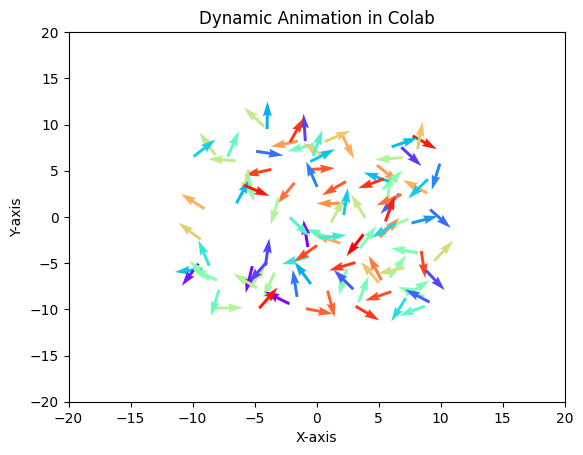

In [42]:
animation = make_animation(savestates)
HTML(animation.to_jshtml())

# Part 4: Quantifying the Model



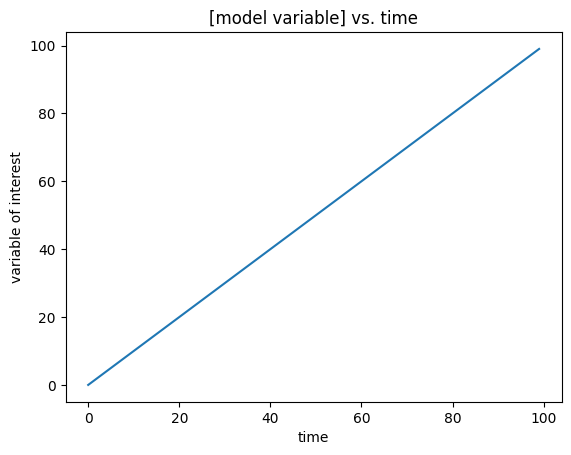

In [24]:
fig, axs = plt.subplots(1, 1) # <- It's worth getting acquainted with subplots!

x = np.arange(0,100)
y = np.arange(0,100) # <- modify the variable of interest here
axs.plot(x,y)
plt.xlabel('time')
plt.ylabel('variable of interest')
plt.title('[model variable] vs. time')

plt.show()

Questions to consider:

*   List item
*   How can we validate this model? How do we do so quantitatively?